In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

df_raw = pd.read_csv('../data/spiff_data-2_filled.csv')

df_raw = df_raw.set_index('day')

df_prices = df_raw[var_names]
print(f"Clean price panel: {df_prices.shape}, days {int(df_prices.index[0])}...{int(df_prices.index[-1])}")
df_prices.tail()

Clean price panel: (5256, 7), days 1...5256


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
5252,13.790362,8.236738,6.451460,6.706903,2.972465,8.751953,11.767324
5253,13.798624,8.134064,6.406032,6.677940,2.960002,8.730038,11.830896
5254,13.800276,8.191484,6.444321,6.655631,2.837448,8.748910,12.129688
5255,13.773631,8.123846,6.370987,6.593250,2.851988,8.742213,12.118563
5256,13.791949,8.084917,6.419011,6.512971,2.760591,8.738561,12.231405


Zentered to mean zero:

In [2]:
df_returns = df_prices.pct_change().dropna()
mean_return = df_returns.mean()
df_returns_centered = df_returns - mean_return
print("Per-series mean return:")
print(mean_return.round(6))
df_returns_centered.head()

Per-series mean return:
gurkor          0.000161
guitars         0.000312
slingshots      0.000317
stocks          0.000017
sugar           0.000079
water           0.000160
tranquillity    0.000165
dtype: float64


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
2,0.005521,0.017146,-0.011060,0.001934,0.009196,0.000807,0.003114
3,-0.003551,-0.001516,0.000986,0.013840,-0.005823,-0.000804,0.013315
4,-0.002145,-0.006038,-0.009861,0.002426,-0.014521,0.000806,-0.005002
5,-0.005273,0.003022,0.001435,0.001083,0.004610,0.000913,0.004290
6,0.003264,0.011168,0.004056,-0.004103,-0.000079,0.001233,-0.004197


In [3]:
Y = df_returns_centered.values                # (T, 7)
T, k = Y.shape

# Build lagged regressors
X = np.column_stack([Y[1:-1], Y[:-2]])        # (T-2, 14): [r_{t-1}, r_{t-2}]
Y_t = Y[2:]                                   # (T-2, 7)

# OLS: B has shape (14, 7); rows 0..6 -> Phi1^T, rows 7..13 -> Phi2^T
B, *_ = np.linalg.lstsq(X, Y_t, rcond=None)
Phi1 = B[:k].T
Phi2 = B[k:].T

# Residual covariance
resid = Y_t - X @ B
Sigma_eps = np.cov(resid, rowvar=False)
L_eps = np.linalg.cholesky(Sigma_eps + 1e-12 * np.eye(k))

print("Phi1 diagonal:", np.round(np.diag(Phi1), 3))
print("Phi2 diagonal:", np.round(np.diag(Phi2), 3))
print(f"Residual std (per series): {np.round(np.sqrt(np.diag(Sigma_eps)), 5)}")


Phi1 diagonal: [-0.012 -0.133 -0.085 -0.001 -0.165 -0.116 -0.034]
Phi2 diagonal: [-0.049 -0.046  0.015 -0.015 -0.06  -0.023 -0.017]
Residual std (per series): [0.00392 0.01446 0.01457 0.01482 0.01346 0.00345 0.01244]


Notice negative diagonals (oscillatory/ one-day mean reversion?)

To avoid exploding process, make sure that no $\lambda$ is outside unit circle.

In [4]:
companion = np.block([[Phi1, Phi2], [np.eye(k), np.zeros((k, k))]])
eigs = np.linalg.eigvals(companion)
print(f"Max |eigenvalue| of companion: {np.max(np.abs(eigs)):.4f}")
assert np.max(np.abs(eigs)) < 1, "VAR(2) is non-stationary"


Max |eigenvalue| of companion: 0.2799


In [5]:
np.random.seed(7)
H = 1000

last_price = df_prices.iloc[-1].values
last_day = int(df_prices.index[-1])

Y_extrap = np.zeros((H + 2, k))
Y_extrap[0] = Y[-2]
Y_extrap[1] = Y[-1]
for t in range(2, H + 2):
    eps =  L_eps @ np.random.randn(k)
    Y_extrap[t] = Phi1 @ Y_extrap[t - 1] + Phi2 @ Y_extrap[t - 2] + eps

# Add the mean back, cumulate from the last observed price
returns_extrap = Y_extrap[2:] + mean_return.values
prices_extrap = last_price * np.cumprod(1.0 + returns_extrap, axis=0)
future_days = np.arange(last_day + 1, last_day + 1 + H)
df_extrap = pd.DataFrame(prices_extrap, index=future_days, columns=var_names)
df_extrap.index.name = 'day'
df_extrap.head()


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
5257,13.887476,8.008653,6.360751,6.542501,2.738954,8.773535,12.193601
5258,13.792457,8.180620,6.499578,6.488390,2.739611,8.758147,12.218436
5259,13.778241,8.043685,6.470970,6.493379,2.773346,8.713028,12.470471
5260,13.791717,7.998533,6.604168,6.496352,2.708043,8.706592,12.130337
5261,13.849444,7.994958,6.493131,6.585448,2.662143,8.740160,11.805486


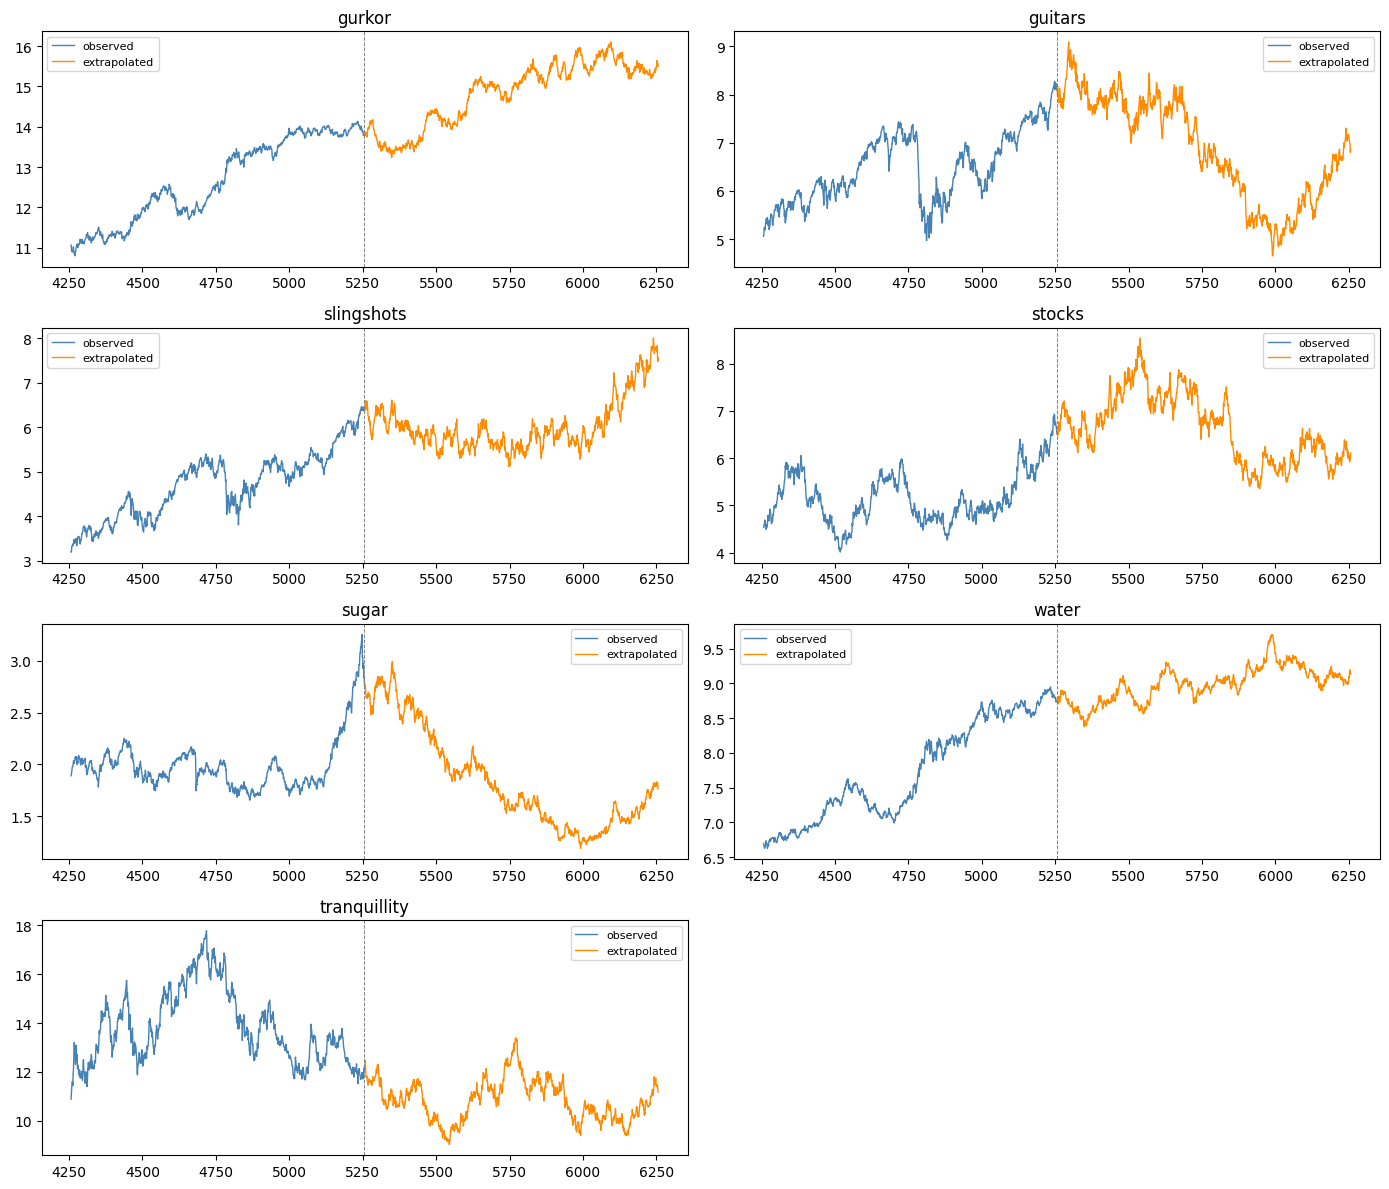

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
tail = 1000
for ax, col in zip(axes.flat, var_names):
    ax.plot(df_prices.index[-tail:], df_prices[col].iloc[-tail:],
            color='steelblue', lw=1, label='observed')
    ax.plot(df_extrap.index, df_extrap[col],
            color='darkorange', lw=1, label='extrapolated')
    ax.axvline(last_day, color='grey', lw=0.7, ls='--')
    ax.set_title(col)
    ax.legend(loc='best', fontsize=8)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()


In [7]:
compare = pd.DataFrame({
    'obs_std':  df_returns_centered.std(),
    'sim_std':  pd.Series(Y_extrap[2:].std(axis=0), index=var_names),
})
print(compare.round(5))

print("\nObserved correlation:")
obs_corr = df_returns_centered.corr()
print(obs_corr.round(2))

print("\nSimulated correlation (300 days — noisy):")
sim_corr = pd.DataFrame(Y_extrap[2:], columns=var_names).corr()
print(sim_corr.round(2))

# Calculate MAE for correlation matrices
mae_corr = np.abs(obs_corr - sim_corr).values.mean()
print(f"\nMAE (correlation matrices): {mae_corr:.5f}")

              obs_std  sim_std
gurkor        0.00393  0.00384
guitars       0.01482  0.01477
slingshots    0.01464  0.01487
stocks        0.01484  0.01452
sugar         0.01512  0.01469
water         0.00350  0.00342
tranquillity  0.01251  0.01248

Observed correlation:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00    -0.24       -0.22   -0.04  -0.07   0.57         -0.14
guitars        -0.24     1.00        0.53    0.01   0.21  -0.23          0.22
slingshots     -0.22     0.53        1.00    0.01   0.12  -0.20          0.19
stocks         -0.04     0.01        0.01    1.00  -0.02  -0.04          0.01
sugar          -0.07     0.21        0.12   -0.02   1.00  -0.07          0.13
water           0.57    -0.23       -0.20   -0.04  -0.07   1.00         -0.16
tranquillity   -0.14     0.22        0.19    0.01   0.13  -0.16          1.00

Simulated correlation (300 days — noisy):
              gurkor  guitars  slingshots  stocks  sugar  wate